# Chapter-10. Pytorch优化器Optimizer

## 【章节目标】
- 理解优化器在模型训练中的作用及其工作原理
- 掌握optimizer的基本属性和方法使用
- 掌握常用优化器的使用方法
- 掌握optimizer的高级用法

## 【章节内容】
### 10.1 理解pytorch优化器
#### 1）回顾机器学习训练步骤

Pytorch中优化器的功能为：管理和更新模型中可学习参数的值，使得模型输出更接近真实标签。

在Pytorch中，自动求导模块可以根据损失函数对模型的参数进行求梯度运算。优化器会获取得到的梯度，然后利用一些策略去更新模型的参数，最终使得损失函数的值下降。

#### 2）Optimizer机制

首先了解一下Pytorch中的优化器Optimizer机制，模型训练时的固定搭配如下：

optimizer.zero_grad()

loss.backward()

optimizer.step()

简单来说：

- 首先optimizer.zero_grad()将梯度清零，防止上一轮梯度影响本轮的参数更新
- 然后loss.backward()就是反向计算出各参数的梯度
- 最后optimizer.step()更新网络中的参数

#### 3）Optimizer基本属性

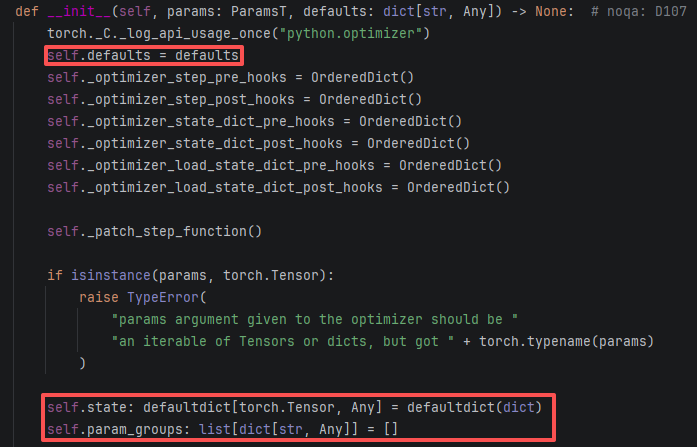

上图为Pytorch源码中Optimizer类的初始化函数，从中可以看出，有基本属性有三个:

- defaults:存储优化器中的超参数，比如学习率，momentum的值等等。

- state:存储的是一些参数的缓存，比如使用动量momentum的时候，他会使用到历史momentum，momentum的值就是存储在state这个属性当中。

- param_groups:pytorch优化器最重要的属性,用来管理参数组的，其作用是存储我们模型中使用的一系列参数的。在Optimizer类的初始化函数中可以看出，param_groups的类型是一个list，其中的每一个元素是一个字典，每个字典的key值才是存储的参数值。结构如下：

- param_groups
    - 0(dict) # 第一组参数  
      params: # 维护要更新的参数  
      lr: # 该组参数的学习率  
      betas:  
      eps: # 该组参数的学习率最小值  
      weight_decay: # 该组参数的权重衰减系数  
    amsgrad:  
    - 1(dict) # 第二组参数
    - 2(dict) # 第三组参数
      ...
      
下面以前面实现的手写数字识别为例：

In [1]:
import torchvision
import torch.nn as nn
import torch
import torch.nn.functional as F
import torch.optim as optim


n_epochs = 3
batch_size_train = 64
learning_rate = 0.01
log_interval = 10
random_seed = 1
torch.manual_seed(random_seed)
train_loader = torch.utils.data.DataLoader(
torchvision.datasets.MNIST('Dataset/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
    batch_size=batch_size_train, shuffle=True)



class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x)
    
network = Net()
loss_func=torch.nn.NLLLoss()
optimizer = optim.SGD(network.parameters(), lr=learning_rate)
# 查看优化器超参数
optimizer.defaults

{'lr': 0.01,
 'momentum': 0,
 'dampening': 0,
 'weight_decay': 0,
 'nesterov': False,
 'maximize': False,
 'foreach': None,
 'differentiable': False,
 'fused': None}

In [2]:
# 查看优化器超参数缓存
optimizer.state

defaultdict(dict, {})

In [3]:
# 查看参数组
optimizer.param_groups

[{'params': [Parameter containing:
   tensor([[[[ 0.1031, -0.0883, -0.0388,  0.0939, -0.1883],
             [ 0.1199, -0.0411,  0.1017,  0.0278, -0.0245],
             [ 0.0555,  0.0099,  0.0730, -0.0779, -0.0146],
             [-0.0180,  0.0290, -0.0008,  0.1748,  0.0622],
             [-0.0745, -0.1208, -0.0335, -0.0863, -0.0641]]],
   
   
           [[[ 0.0096,  0.1192,  0.1087, -0.1955,  0.1240],
             [ 0.0559,  0.1897,  0.1320, -0.1822, -0.1902],
             [-0.0965,  0.1756, -0.0333,  0.0856, -0.0929],
             [ 0.1962, -0.0846,  0.1500,  0.0024, -0.1054],
             [ 0.1028, -0.1062,  0.0588, -0.0578, -0.0219]]],
   
   
           [[[-0.1923, -0.0954,  0.1085, -0.0486,  0.1992],
             [ 0.1603, -0.0094, -0.1335,  0.1218,  0.0621],
             [-0.1293,  0.1299,  0.1214,  0.1774, -0.1121],
             [-0.0329, -0.0039,  0.0292, -0.1518, -0.1419],
             [ 0.1088, -0.0469,  0.0977,  0.0114,  0.0657]]],
   
   
           [[[ 0.0440,  0.0727,  0.

In [4]:
for k in optimizer.param_groups[0]['params']:
    print(k.shape)

torch.Size([10, 1, 5, 5])
torch.Size([10])
torch.Size([20, 10, 5, 5])
torch.Size([20])
torch.Size([50, 320])
torch.Size([50])
torch.Size([10, 50])
torch.Size([10])


#### 4）Optimizer基本方法
##### 4.1 zero_grad()：清空所有管理参数的梯度  
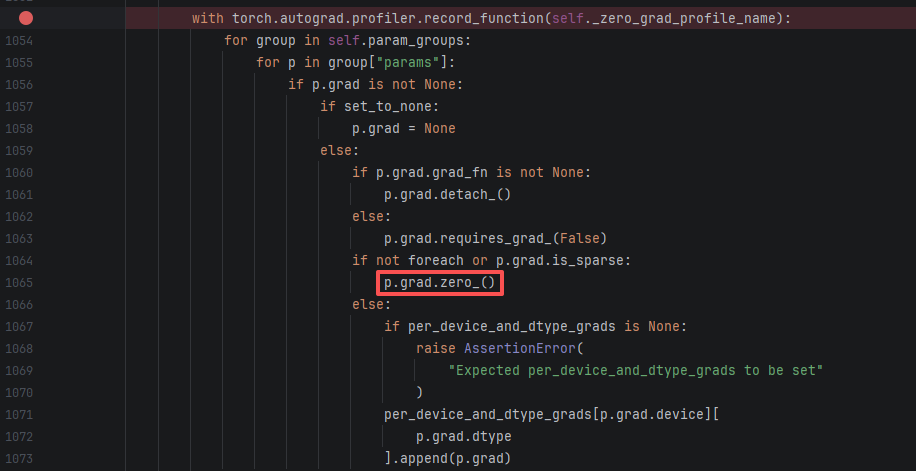

zero_grad()函数的作用为清空每一个参数梯度值。

在pytorch中，每一次进行反向传播的时候，自动求导器得到的梯度，会加到张量已有的grad属性上面。

因此，我们在使用完梯度，或者是在进行梯度求导之前，需要把已有的梯度进行清零。

这就是zero_grad的需要使用的原因。

##### 4.2 step()：执行一步参数更新操作

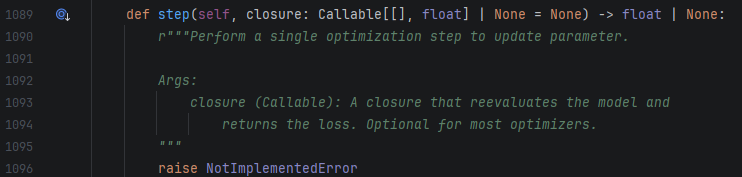

当我们反向传播获得了梯度之后，就需要通过step()方法进行一步的权值参数更新

从Optimizer的源码中可以看到，step方法没有实现，将来 由继承的子类实现step功能，因为不同的优化器进行参数更新的方式不一样。

观察SGD优化器的step方法：(老版本，新版本源码变长很多逻辑差不多，这里不特别记录)  
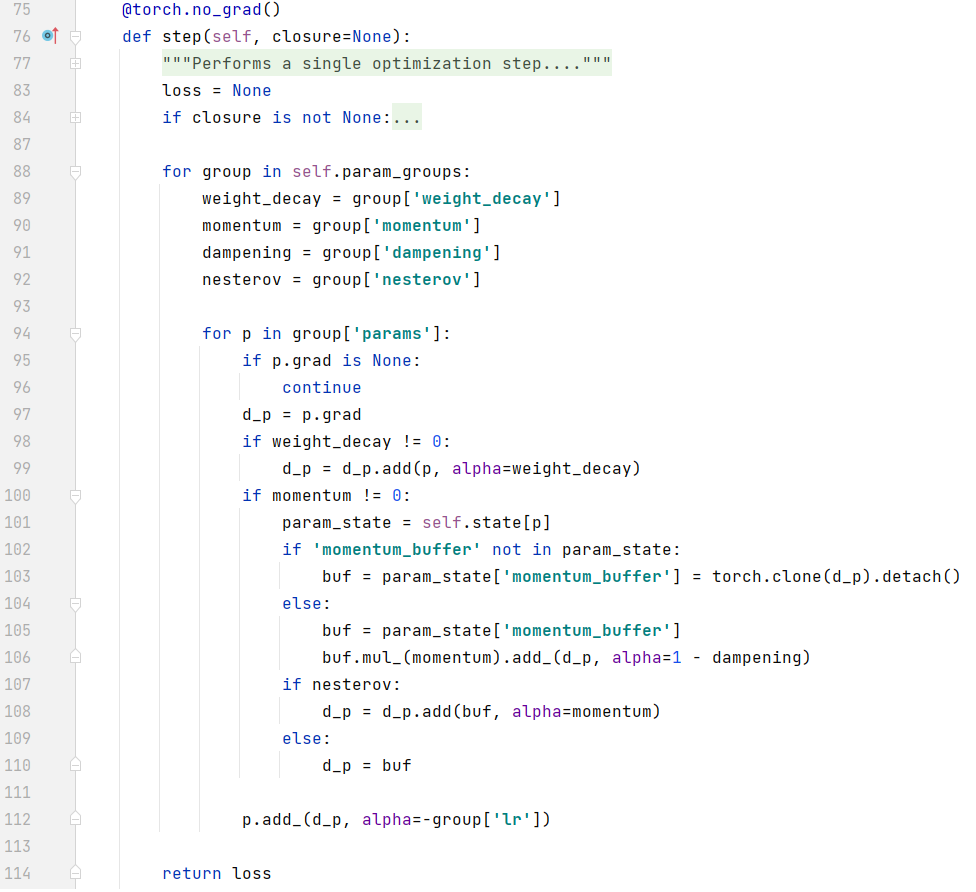

##### 4.3 add_param_group（）：往优化器中添加参数组 （后面主要还是参考老代码，逻辑简单清晰一些）
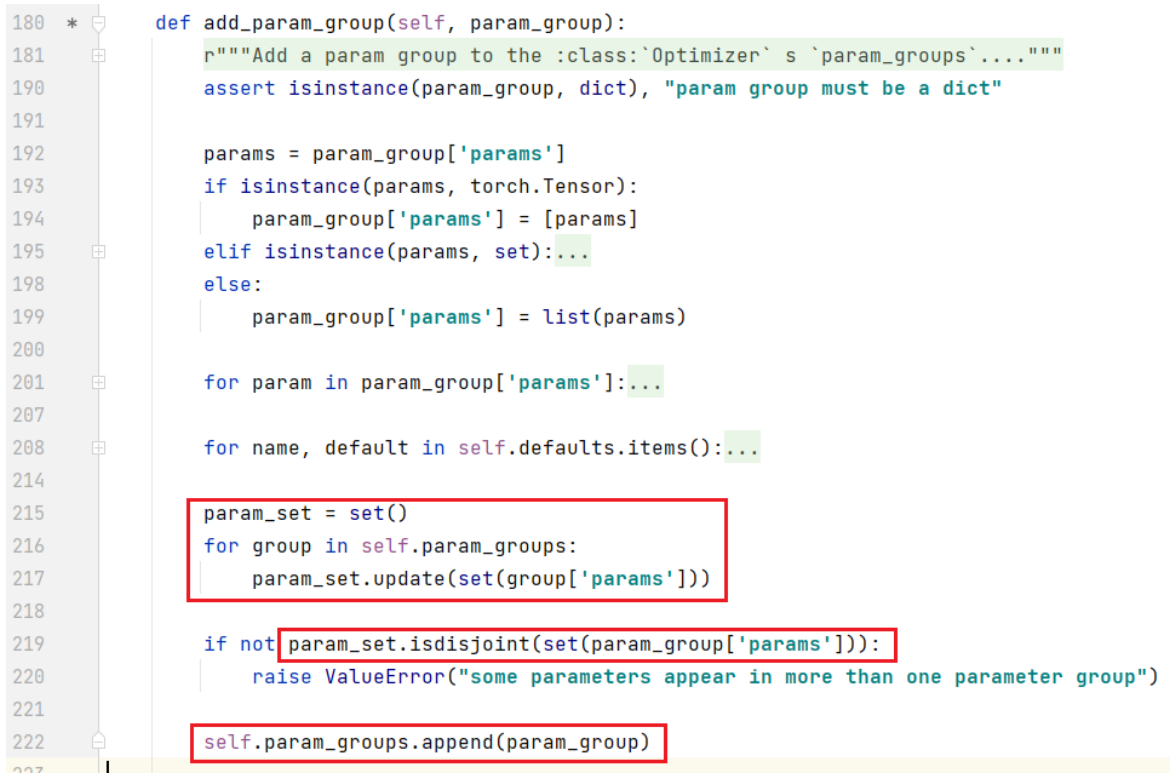

- 优化器需要管理很多的参数，pytorch中可以对不同的参数进行分组。

- 参数分组后可以对每组的参数设置不同的超参数，比如对模型的不同参数设置不同的学习率。

- param_groups是一个list，每个元素中存储的是一组参数。

- 这个函数接收的参数是param_group必须是一个字典。

**使用示例代码：**

In [7]:
optimizer = optim.SGD(network.conv1.parameters(), lr = 0.01) # 初始化的时只给conv1层的参数
optimizer.add_param_group({"params":network.conv2.parameters(), "lr":0.05})
optimizer.add_param_group({"params":network.fc1.parameters(), "lr":0.1})
optimizer.add_param_group({"params":network.fc2.parameters(), "lr":0.1})

optimizer.param_groups, len(optimizer.param_groups)

([{'params': [Parameter containing:
    tensor([[[[ 0.1031, -0.0883, -0.0388,  0.0939, -0.1883],
              [ 0.1199, -0.0411,  0.1017,  0.0278, -0.0245],
              [ 0.0555,  0.0099,  0.0730, -0.0779, -0.0146],
              [-0.0180,  0.0290, -0.0008,  0.1748,  0.0622],
              [-0.0745, -0.1208, -0.0335, -0.0863, -0.0641]]],
    
    
            [[[ 0.0096,  0.1192,  0.1087, -0.1955,  0.1240],
              [ 0.0559,  0.1897,  0.1320, -0.1822, -0.1902],
              [-0.0965,  0.1756, -0.0333,  0.0856, -0.0929],
              [ 0.1962, -0.0846,  0.1500,  0.0024, -0.1054],
              [ 0.1028, -0.1062,  0.0588, -0.0578, -0.0219]]],
    
    
            [[[-0.1923, -0.0954,  0.1085, -0.0486,  0.1992],
              [ 0.1603, -0.0094, -0.1335,  0.1218,  0.0621],
              [-0.1293,  0.1299,  0.1214,  0.1774, -0.1121],
              [-0.0329, -0.0039,  0.0292, -0.1518, -0.1419],
              [ 0.1088, -0.0469,  0.0977,  0.0114,  0.0657]]],
    
    
            [

In [8]:
#等价的一个写法
params=[{"params":network.conv1.parameters(),"lr":0.01},
        {"params":network.conv2.parameters(),"lr":0.05},
       {"params":network.fc1.parameters(),"lr":0.1},
       {"params":network.fc2.parameters(),"lr":0.1}]
optimizer = optim.SGD(params)
optimizer.param_groups

[{'params': [Parameter containing:
   tensor([[[[ 0.1031, -0.0883, -0.0388,  0.0939, -0.1883],
             [ 0.1199, -0.0411,  0.1017,  0.0278, -0.0245],
             [ 0.0555,  0.0099,  0.0730, -0.0779, -0.0146],
             [-0.0180,  0.0290, -0.0008,  0.1748,  0.0622],
             [-0.0745, -0.1208, -0.0335, -0.0863, -0.0641]]],
   
   
           [[[ 0.0096,  0.1192,  0.1087, -0.1955,  0.1240],
             [ 0.0559,  0.1897,  0.1320, -0.1822, -0.1902],
             [-0.0965,  0.1756, -0.0333,  0.0856, -0.0929],
             [ 0.1962, -0.0846,  0.1500,  0.0024, -0.1054],
             [ 0.1028, -0.1062,  0.0588, -0.0578, -0.0219]]],
   
   
           [[[-0.1923, -0.0954,  0.1085, -0.0486,  0.1992],
             [ 0.1603, -0.0094, -0.1335,  0.1218,  0.0621],
             [-0.1293,  0.1299,  0.1214,  0.1774, -0.1121],
             [-0.0329, -0.0039,  0.0292, -0.1518, -0.1419],
             [ 0.1088, -0.0469,  0.0977,  0.0114,  0.0657]]],
   
   
           [[[ 0.0440,  0.0727,  0.

##### 4.4 state_dict()：获取优化器当前状态信息字典

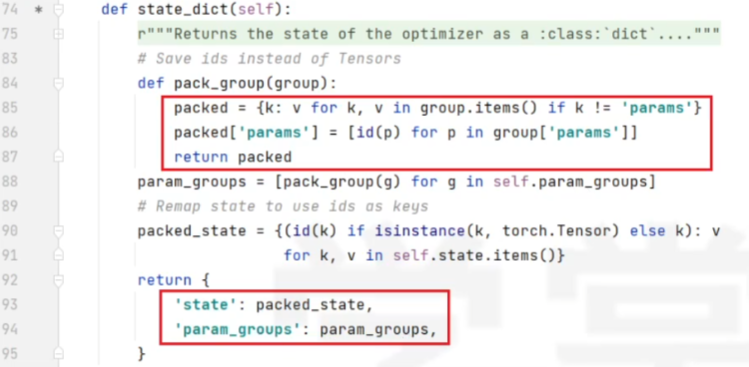

可以看到该函数返回的是个字典，字典有两个key。

一个是state键对应的value，刚才说过这里边存储的是缓存信息。

还有一个是param_groups键对应的value里边存储的是管理哪些参数。

**代码验证**

In [9]:
network = Net()
loss_func = torch.nn.NLLLoss()
optimizer = optim.SGD(network.parameters(), lr = learning_rate, momentum = 0.9)
network.train()
for batch_idx, (data, target) in enumerate((train_loader)):
    optimizer.zero_grad()
    output = network(data)
    loss = loss_func(output, target)
    loss.backward()
    optimizer.step()
    print("batch:", batch_idx, optimizer.state_dict())
    if batch_idx > 3:
        break

C:\Users\lenovo\AppData\Local\Temp\ipykernel_40732\2194864973.py:40: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


batch: 0 {'state': {0: {'momentum_buffer': tensor([[[[ 2.1091e-02,  1.9251e-02,  1.7862e-02,  8.3078e-03,  1.3994e-03],
          [ 1.5105e-02,  1.9500e-02,  2.6317e-02,  1.6919e-02, -5.7182e-04],
          [ 2.5915e-03,  9.4457e-03,  1.9330e-02,  1.3917e-02, -1.0250e-02],
          [ 1.2238e-03,  7.3133e-03,  1.5156e-02,  6.7841e-03, -6.5967e-03],
          [-3.6155e-03,  8.4504e-03,  1.5909e-02,  5.7541e-03,  7.6710e-04]]],


        [[[ 6.0472e-03,  6.7310e-03,  7.5190e-03,  7.0359e-03,  5.7314e-03],
          [-1.8456e-03,  9.5748e-04,  4.2716e-03,  7.7887e-03,  1.0208e-02],
          [-4.5677e-03, -5.3457e-03, -1.1071e-03,  1.4113e-02,  2.0495e-02],
          [-7.5252e-03, -7.3812e-03,  6.3638e-04,  1.5850e-02,  2.4099e-02],
          [-2.5338e-03,  1.3256e-04,  1.4787e-02,  2.4363e-02,  2.3051e-02]]],


        [[[-1.5210e-02, -1.6038e-02, -5.8422e-03, -9.4709e-04,  2.4809e-03],
          [-2.0690e-02, -2.3745e-02, -1.5481e-02, -5.9553e-03,  5.2986e-03],
          [-2.2983e-02, -

##### 4.5 load_state_dict()：加载状态信息字典

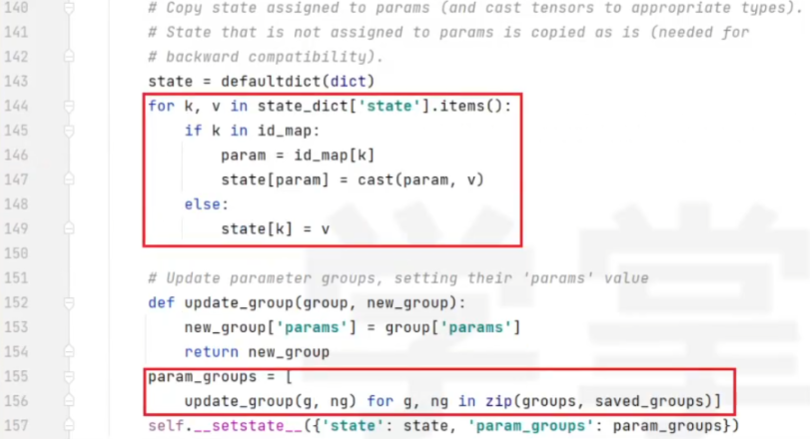

- 该函数和刚才state_dict()函数的功能刚好相反，功能是加载装填信息字典，该函数接受到的是一个状态字典，然后放到优化器当中。


- state_dict()，load_state_dict()两个函数可以实现模型的断点续训练。如果模型训练到一半有事要停下来，完事下次还想从上次训练的地方接着训练，就可以使用这两个函数来完成这个事情。

In [10]:
optimizer2 = optim.SGD(network.parameters(), lr = 0.1)
optimizer2.load_state_dict(optimizer.state_dict())
optimizer2.state_dict()

{'state': {0: {'momentum_buffer': tensor([[[[ 0.0511,  0.0559,  0.0463,  0.0089,  0.0045],
             [ 0.0353,  0.0368,  0.0248, -0.0046, -0.0220],
             [ 0.0150,  0.0172,  0.0064, -0.0126, -0.0368],
             [ 0.0079,  0.0095, -0.0002, -0.0161, -0.0361],
             [ 0.0032,  0.0011, -0.0055, -0.0139, -0.0238]]],
   
   
           [[[ 0.0031,  0.0161,  0.0216,  0.0128,  0.0022],
             [ 0.0028,  0.0094,  0.0165,  0.0079,  0.0013],
             [ 0.0011, -0.0029,  0.0090,  0.0183,  0.0067],
             [-0.0048, -0.0068,  0.0073,  0.0091, -0.0019],
             [-0.0021, -0.0048,  0.0114,  0.0024, -0.0138]]],
   
   
           [[[-0.0100, -0.0051,  0.0019,  0.0022,  0.0116],
             [-0.0319, -0.0143, -0.0120, -0.0046,  0.0065],
             [-0.0273, -0.0149, -0.0093, -0.0072, -0.0003],
             [-0.0169, -0.0086,  0.0029, -0.0056,  0.0054],
             [-0.0069, -0.0035,  0.0147,  0.0091, -0.0044]]],
   
   
           [[[ 0.0086,  0.0174, -0.0023

### 10.2 pytorch中实现的十种优化器

PyTorch提供了十种优化器，都在torch.optim包中：

- optim.SGD：随机梯度下降法
- optim.Adagrad：自适应学习率梯度下降法
- optim.RMSprop：Adagrad的改进
- optim.Adadelta：Adagrad的改进
- optim.Adam：RMSprop结合Momentum
- optim.Adamax：Adam增加学习率上限
- optim.SparseAdam：稀疏版Adam
- optim.ASGD：随机平均梯度下降
- optim.Rprop：弹性反向传播
- optim.LBFGS：BFGS的改进

#### 1）SGD

torch.optim.SGD(params, lr=0.01, momentum=0, dampening=0, weight_decay=0, nesterov=False)

**功能:**

可实现SGD优化算法，带动量SGD优化算法，带NAG(Nesterov accelerated gradient)动量SGD优化算法,并且均可拥有weight_decay项。

**参数:**

- params(iterable)- 参数组。

- lr(float)- 初始学习率，可按需随着训练过程不断调整学习率。

- momentum(float)- 动量，通常设置为0.9，0.8

- dampening(float)- dampening for momentum ，暂时不了解其功能，在源码中是这样用的：buf.mul_(momentum).add_(1 - dampening, d_p)，值得注意的是，若采用nesterov，dampening必须为 0.

- weight_decay(float)- 权值衰减系数，也就是L2正则项的系数

- nesterov(bool)- bool选项，是否使用NAG(Nesterov accelerated gradient)


**注意事项：**

pytroch中使用SGD十分需要注意的是，更新公式与其他框架略有不同！

pytorch中是这样的：

v=ρ∗v+g

p=p−lr∗v = p - lr∗ρ∗v - lr∗g

其他框架：

v=ρ∗v+lr∗g

p=p−v = p - ρ∗v - lr∗g

ρ是动量，v是速率，g是梯度，p是参数，其实差别就是在ρ∗v这一项，pytorch中将此项也乘了一个学习率。

#### 2）ASGD

torch.optim.ASGD(params, lr=0.01, lambd=0.0001, alpha=0.75, t0=1000000.0, weight_decay=0)

**功能:**

ASGD也成为SAG，均表示随机平均梯度下降(Averaged Stochastic Gradient Descent)，简单地说ASGD就是用空间换时间的一种SGD，详细可参看论文：http://riejohnson.com/rie/stograd_nips.pdf

**参数:**

- params(iterable)- 参数组。

- lr(float)- 初始学习率，可按需随着训练过程不断调整学习率。

- lambd(float)- 衰减项，默认值1e-4。

- alpha(float)- power for eta update ，默认值0.75。

- t0(float)- point at which to start averaging，默认值1e6。

- weight_decay(float)- 权值衰减系数，也就是L2正则项的系数。

#### 3）Rprop

torch.optim.Rprop(params, lr=0.01, etas=(0.5, 1.2), step_sizes=(1e-06, 50))

**功能:**

实现Rprop优化方法(弹性反向传播)，优化方法原文《Martin Riedmiller und Heinrich Braun: Rprop - A Fast Adaptive Learning Algorithm. Proceedings of the International Symposium on Computer and Information Science VII, 1992》

该优化方法适用于full-batch，不适用于mini-batch，因而在min-batch大行其道的时代里，很少见到。

#### 4）Adagrad

torch.optim.Adagrad(params, lr=0.01, lr_decay=0, weight_decay=0, initial_accumulator_value=0)

**功能:**

实现Adagrad优化方法(Adaptive Gradient)，Adagrad是一种自适应优化方法，是自适应的为各个参数分配不同的学习率。

这个学习率的变化，会受到梯度的大小和迭代次数的影响。梯度越大，学习率越小；梯度越小，学习率越大。

缺点是训练后期，学习率过小，因为Adagrad累加之前所有的梯度平方作为分母。

#### 5）Adadelta

torch.optim.Adadelta(params, lr=1.0, rho=0.9, eps=1e-06, weight_decay=0

**功能:**

实现Adadelta优化方法。Adadelta是Adagrad的改进。Adadelta分母中采用距离当前时间点比较近的累计项，这可以避免在训练后期，学习率过小。

#### 6）RMSprop

torch.optim.RMSprop(params, lr=0.01, alpha=0.99, eps=1e-08, weight_decay=0, momentum=0, centered=False)

**功能:**

实现RMSprop优化方法（Hinton提出），RMS是均方根（root meam square）的意思。


RMSprop和Adadelta一样，也是对Adagrad的一种改进。


RMSprop采用均方根作为分母，可缓解Adagrad学习率下降较快的问题。并且引入均方根，可以减少摆动

#### 7）Adam(AMSGrad)

torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)

**功能:**

- 实现Adam(Adaptive Moment Estimation))优化方法。


- Adam是一种自适应学习率的优化方法，Adam利用梯度的一阶矩估计和二阶矩估计动态的调整学习率。


- Adam是结合了Momentum和RMSprop，并进行了偏差修正。

- amsgrad- 是否采用AMSGrad优化方法，asmgrad优化方法是针对Adam的改进，通过添加额外的约束，使学习率始终为正值。

#### 8）Adamax

torch.optim.Adamax(params, lr=0.002, betas=(0.9, 0.999), eps=1e-08, weight_decay=0)

**功能:**

实现Adamax优化方法。Adamax是对Adam增加了一个学习率上限的概念，所以也称之为Adamax。

#### 9）SparseAdam

torch.optim.SparseAdam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-08)

**功能:**

针对稀疏张量的一种“阉割版”Adam优化方法。

#### 10）LBFGS

torch.optim.LBFGS(params, lr=1, max_iter=20, max_eval=None, tolerance_grad=1e-05, tolerance_change=1e-09, history_size=100, line_search_fn=None)

**功能：**

实现L-BFGS（Limited-memory Broyden–Fletcher–Goldfarb–Shanno）优化方法。L-BFGS属于拟牛顿算法。L-BFGS是对BFGS的改进，特点就是节省内存。

### 10.3 各种优化器实战手写数字识别

In [4]:
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

n_epochs = 3
batch_size_train = 64
batch_size_test=256
learning_rate = 0.01
log_interval = 10
random_seed = 1
torch.manual_seed(random_seed)
train_loader = torch.utils.data.DataLoader(
torchvision.datasets.MNIST('Dataset/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(
torchvision.datasets.MNIST('Dataset/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),batch_size=batch_size_test, shuffle=True)


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [5]:
def train(opt):
    network = Net()
    loss_func=torch.nn.NLLLoss()
    optimizer = opt(network.parameters(), lr=learning_rate)
    network.train()
    losses=[]
    for epoch in  range(n_epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = network(data)
            loss = loss_func(output, target)
            loss.backward()
            optimizer.step()
            # 修改：使用 .item() 只记录数值，释放计算图内存
            losses.append(loss.item())
            
            if batch_idx % log_interval == 0:
                print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')
    return losses

In [6]:
losses={}
losses['sgd']=train(optim.SGD)
losses['asgd']=train(optim.ASGD)
losses['adagrad']=train(optim.Adagrad)
losses['adadelta']=train(optim.Adadelta)
losses['rmsprop']=train(optim.RMSprop)
losses['adam']=train(optim.Adam)
losses['adamax']=train(optim.Adamax)

Epoch: 0 [0/60000] Loss: 2.329236
Epoch: 0 [640/60000] Loss: 2.342286
Epoch: 0 [1280/60000] Loss: 2.301460
Epoch: 0 [1920/60000] Loss: 2.292632
Epoch: 0 [2560/60000] Loss: 2.317862
Epoch: 0 [3200/60000] Loss: 2.282153
Epoch: 0 [3840/60000] Loss: 2.288397
Epoch: 0 [4480/60000] Loss: 2.255736
Epoch: 0 [5120/60000] Loss: 2.246160
Epoch: 0 [5760/60000] Loss: 2.200378
Epoch: 0 [6400/60000] Loss: 2.234580
Epoch: 0 [7040/60000] Loss: 2.245217
Epoch: 0 [7680/60000] Loss: 2.171275
Epoch: 0 [8320/60000] Loss: 2.176266
Epoch: 0 [8960/60000] Loss: 2.155564
Epoch: 0 [9600/60000] Loss: 2.183090
Epoch: 0 [10240/60000] Loss: 2.103437
Epoch: 0 [10880/60000] Loss: 2.066558
Epoch: 0 [11520/60000] Loss: 1.963337
Epoch: 0 [12160/60000] Loss: 1.898690
Epoch: 0 [12800/60000] Loss: 1.980053
Epoch: 0 [13440/60000] Loss: 1.892607
Epoch: 0 [14080/60000] Loss: 1.904266
Epoch: 0 [14720/60000] Loss: 1.849949
Epoch: 0 [15360/60000] Loss: 1.728899
Epoch: 0 [16000/60000] Loss: 1.587752
Epoch: 0 [16640/60000] Loss: 1.5

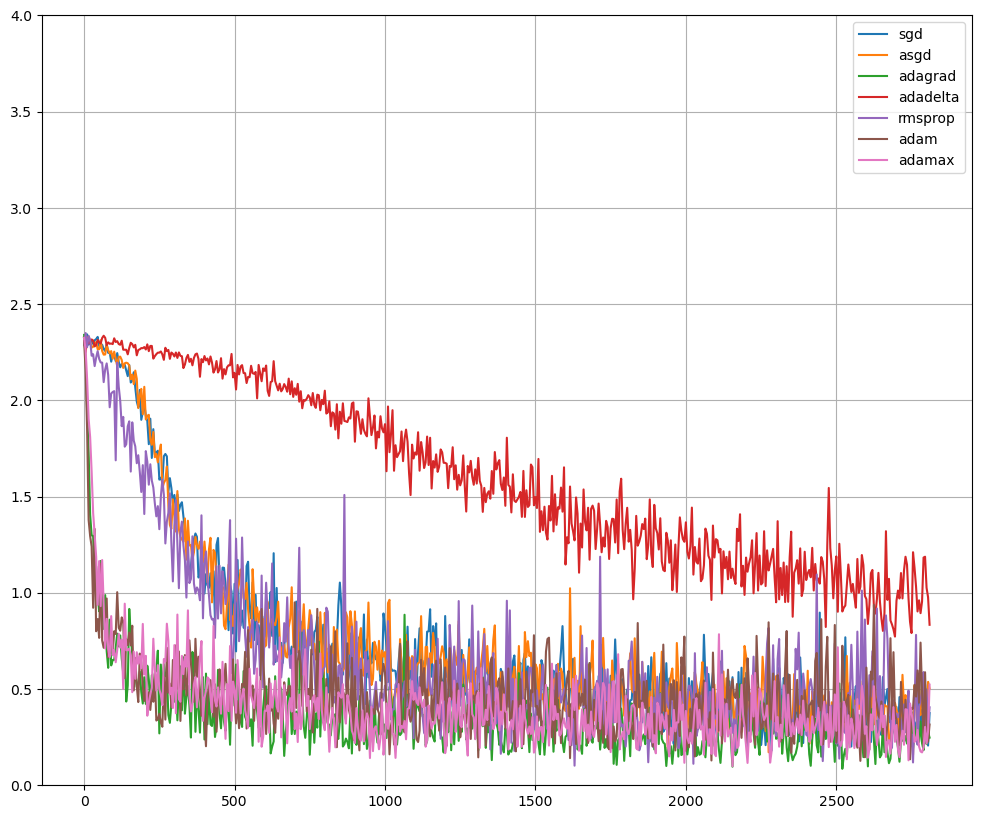

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 10))
#x = range(len(list(losses.values())[0]))
for k, v in losses.items():
    # v = [float(item.detach().numpy()) for item in v]
    # print(v)
    # 上面用了 .item()，这里 v 已经是纯浮点数列表了，不需要再转
    x = range(len(v))
    plt.plot(x[::5], v[::5], label = k)

plt.legend()
plt.ylim(0, 4)
plt.grid()
plt.show()

### 10.4 优化器高级用法

#### 1）只训练模型的一部分参数
例如，只想训练上面的model中的fc2参数，而保持其他层的参数不动。可以如下设置Optimizer：

**代码示例**

In [ ]:
model = Net()
# 只传入fc2层的参数，就可以只更新layer层的参数而不影响其他参数。
optimizer_Adam = torch.optim.Adam(model.fc2.parameters(), lr=0.1)  

#### 2）不同部分的参数设置不同的学习率

例如，要想使model的conv层参数学习率为0.1，fc的参数学习率为0.2，可以如下设置Optimizer：

In [ ]:
model = Net()
params_dict = [{'params': model.conv1.parameters(), 'lr': 0.1},  
               {'params': model.conv2.parameters(), 'lr': 0.1},  
              {'params': model.fc1.parameters(), 'lr': 0.2},
              {'params': model.fc2.parameters(), 'lr': 0.2}]
optimizer_Adam = torch.optim.Adam(params_dict)

#### 3）累计梯度变相扩大batch_size

如果我们的机器性能(如内存条不够大)首先导致batch_size只能为4，但是我们想使用比较大的批次，可以按照如下的方法操作：

**代码示例**

In [ ]:
network = Net()
loss_func=torch.nn.NLLLoss()
optimizer = optim.Adam(network.parameters(), lr=learning_rate)
n_batch=3
n=len(train_loader)
network.train()
for epoch in  range(n_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        if (epoch*n+batch_idx)%n_batch==0:#每隔3次清零一次梯度
            optimizer.zero_grad()
        output = network(data)
        loss = loss_func(output, target)
        loss.backward()
        if (epoch*n+batch_idx+1)%n_batch==0:#每隔3次更新一次参数
            optimizer.step()

### 10.5 正则化之weight decay（权重衰减） 

注：pytorch正则化是通过优化器实现，可能和别的框架不太一样

#### 1）正则化作用-防止过拟合

目标函数(Objective Function)：

obj = cost + Regula riza tion Term


- L1 Regularization Term: $\Large \sum_{i}^{N}\vert w_i \vert$

- L2 Regularization Term: $\Large \sum_{i}^{N} w_i^2 $

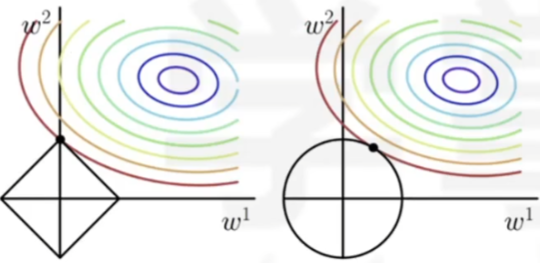

#### 2）pytorch实现weightdecay

pytorch中的**L2正则化（L1要手动实现）**是通过optimizer来实现的。

**optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=0.9)**

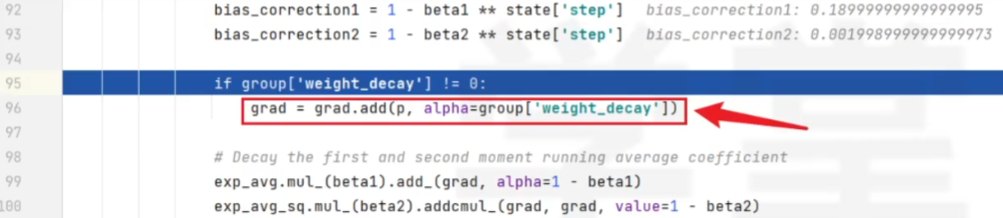